## Loading Libraries

In [9]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import plotly.express as px
import folium

from tqdm import tqdm
from pathlib import Path

## Creating Dummy Data

In [10]:
trip_demo = pd.DataFrame({
    "ride_id": list(range(1, 21)),

    "start_station": [
        "Station A", "Station A", "Station A", "Station A", "Station A",
        "Station B", "Station B", "Station B", "Station B",
        "Station C", "Station C", "Station C",
        "Station D", "Station D", "Station D",
        "Station E", "Station E",
        "Station A", "Station B", "Station C"
    ],

    "end_station": [
        "Station B", "Station B", "Station B", "Station C", "Station C",
        "Station A", "Station A", "Station C", "Station D",
        "Station A", "Station B", "Station E",
        "Station A", "Station C", "Station E",
        "Station A", "Station D",
        "Station E", "Station E", "Station D"
    ],

    "started_at": pd.to_datetime([
        "2025-01-01 08:00", "2025-01-01 08:15", "2025-01-01 08:30",
        "2025-01-01 09:00", "2025-01-01 09:20",
        "2025-01-01 10:00", "2025-01-01 10:15", "2025-01-01 10:40",
        "2025-01-01 11:00",
        "2025-01-01 11:30", "2025-01-01 12:00", "2025-01-01 12:20",
        "2025-01-01 13:00", "2025-01-01 13:30", "2025-01-01 14:00",
        "2025-01-01 14:30", "2025-01-01 15:00",
        "2025-01-01 15:30", "2025-01-01 16:00", "2025-01-01 16:30"
    ]),

    "ended_at": pd.to_datetime([
        "2025-01-01 08:10", "2025-01-01 08:28", "2025-01-01 08:42",
        "2025-01-01 09:18", "2025-01-01 09:35",
        "2025-01-01 10:12", "2025-01-01 10:30", "2025-01-01 10:55",
        "2025-01-01 11:18",
        "2025-01-01 11:48", "2025-01-01 12:14", "2025-01-01 12:45",
        "2025-01-01 13:20", "2025-01-01 13:48", "2025-01-01 14:20",
        "2025-01-01 14:55", "2025-01-01 15:22",
        "2025-01-01 15:58", "2025-01-01 16:25", "2025-01-01 16:50"
    ]),

    "member_casual": [
        "member", "member", "casual", "member", "casual",
        "member", "member", "casual", "member",
        "casual", "member", "casual",
        "member", "casual", "member",
        "casual", "member",
        "member", "casual", "member"
    ]
})

trip_demo

,ride_id,start_station,end_station,started_at,ended_at,member_casual
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual
5,6,Station B,Station A,2025-01-01 10:00:00,2025-01-01 10:12:00,member
6,7,Station B,Station A,2025-01-01 10:15:00,2025-01-01 10:30:00,member
7,8,Station B,Station C,2025-01-01 10:40:00,2025-01-01 10:55:00,casual
8,9,Station B,Station D,2025-01-01 11:00:00,2025-01-01 11:18:00,member
9,10,Station C,Station A,2025-01-01 11:30:00,2025-01-01 11:48:00,casual


In [11]:
station_coordinates = pd.DataFrame({
    "station": [
        "Station A",
        "Station B",
        "Station C",
        "Station D",
        "Station E"
    ],
    "lat": [
        40.735,
        40.751,
        40.742,
        40.728,
        40.760
    ],
    "lng": [
        -73.991,
        -73.977,
        -73.985,
        -73.970,
        -73.995
    ]
})

station_coordinates

,station,lat,lng
0,Station A,40.735,-73.991
1,Station B,40.751,-73.977
2,Station C,40.742,-73.985
3,Station D,40.728,-73.970
4,Station E,40.760,-73.995


In [5]:
start_df = trip_demo.merge(station_coordinates,how='left',left_on='start_station',right_on='station')
start_df.rename(columns={
    'lat':'start_lat',
    'lng': 'start_lng'    
}, inplace = True)



In [6]:
end_df = trip_demo.merge(station_coordinates,how='left',left_on='end_station',right_on='station')

end_df.rename(columns={
    'lat':'end_lat',
    'lng': 'end_lng'    
}, inplace = True)

end_df.drop(columns=['station'], inplace=True)
end_df.head()

,ride_id,start_station,end_station,started_at,ended_at,member_casual,end_lat,end_lng
0,1,Station A,Station B,2025-01-01 08:00:00,2025-01-01 08:10:00,member,40.751,-73.977
1,2,Station A,Station B,2025-01-01 08:15:00,2025-01-01 08:28:00,member,40.751,-73.977
2,3,Station A,Station B,2025-01-01 08:30:00,2025-01-01 08:42:00,casual,40.751,-73.977
3,4,Station A,Station C,2025-01-01 09:00:00,2025-01-01 09:18:00,member,40.742,-73.985
4,5,Station A,Station C,2025-01-01 09:20:00,2025-01-01 09:35:00,casual,40.742,-73.985


In [7]:

start_cols = ['ride_id', 'start_station','started_at','start_lat', 'start_lng']
end_cols = ['ride_id', 'end_station','ended_at','end_lat', 'end_lng', 'member_casual']

In [20]:
trip_demo = pd.merge(start_df[start_cols], end_df[end_cols],how='inner', on= 'ride_id')
trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual


In [21]:
map_center = [
    pd.concat([trip_demo["start_lat"], trip_demo["end_lat"]]).mean(),
    pd.concat([trip_demo["start_lng"], trip_demo["end_lng"]]).mean()
]

map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [22]:
trip_demo["duration_min"] = (
    trip_demo["ended_at"] - trip_demo["started_at"]
).dt.total_seconds() / 60

trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0


In [23]:
trip_demo["date"] = trip_demo["started_at"].dt.date
trip_demo["hour"] = trip_demo["started_at"].dt.hour
trip_demo["day_name"] = trip_demo["started_at"].dt.day_name()
trip_demo["month_name"] = trip_demo["started_at"].dt.month_name()

trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,date,hour,day_name,month_name
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2025-01-01,8,Wednesday,January
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2025-01-01,8,Wednesday,January
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2025-01-01,8,Wednesday,January
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,2025-01-01,9,Wednesday,January
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,2025-01-01,9,Wednesday,January


## Folium

In [24]:
map_center

[np.float64(40.7427), np.float64(-73.9841)]

In [29]:
m = folium.Map(
    location=map_center,
    zoom_start=13
)
m

In [39]:
for _, row in station_coordinates.iterrows():
    folium.Marker(
        location=[row["lat"], row["lng"]],
        popup=row["station"],
        tooltip = row['station']
    ).add_to(m)

m

In [46]:
# m = folium.Map(
#     location=map_center,
#     zoom_start=13
# )

start_point = [trip_demo.loc[0, "start_lat"], trip_demo.loc[0, "start_lng"]]
end_point = [trip_demo.loc[0, "end_lat"], trip_demo.loc[0, "end_lng"]]

folium.Marker(start_point, popup="Start").add_to(m)
folium.Marker(end_point, popup="End").add_to(m)

folium.PolyLine(
    locations=[start_point, end_point],
    weight=5,
    opacity=0.8
).add_to(m)

m

In [ ]:
import geopandas as gpd
start_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["start_lng"],
        trip_demo["start_lat"]
    ),
    crs="EPSG:4326"
)

end_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["end_lng"],
        trip_demo["end_lat"]
    ),
    crs="EPSG:4326"
)

In [48]:
import geopandas  as gpd

In [49]:
start_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["start_lng"],
        trip_demo["start_lat"]
    ),
    crs="EPSG:4326"
)

<Axes: >

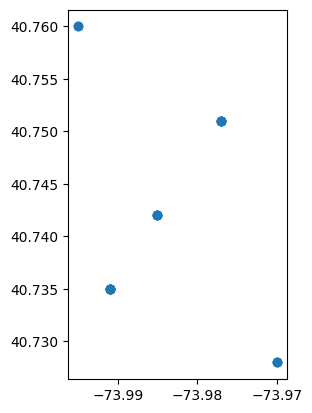

In [50]:
start_points.plot()

<Axes: >

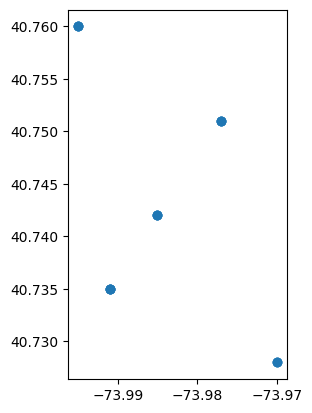

In [53]:
end_points = gpd.GeoDataFrame(
    trip_demo.copy(),
    geometry=gpd.points_from_xy(
        trip_demo["end_lng"],
        trip_demo["end_lat"]
    ),
    crs="EPSG:4326"
)

end_points.plot()

In [54]:
projected_crs = "EPSG:32618"

start_points_projected = start_points.to_crs(projected_crs)
end_points_projected = end_points.to_crs(projected_crs)

In [58]:
trip_demo["distance_m"] = start_points_projected.geometry.distance(
    end_points_projected.geometry
)

trip_demo["distance_km"] = trip_demo["distance_m"] / 1000


trip_demo.head()

,ride_id,start_station,started_at,start_lat,start_lng,end_station,ended_at,end_lat,end_lng,member_casual,duration_min,date,hour,day_name,month_name,distance_m,distance_km
0,1,Station A,2025-01-01 08:00:00,40.735,-73.991,Station B,2025-01-01 08:10:00,40.751,-73.977,member,10.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
1,2,Station A,2025-01-01 08:15:00,40.735,-73.991,Station B,2025-01-01 08:28:00,40.751,-73.977,member,13.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
2,3,Station A,2025-01-01 08:30:00,40.735,-73.991,Station B,2025-01-01 08:42:00,40.751,-73.977,casual,12.0,2025-01-01,8,Wednesday,January,2133.621698,2.133622
3,4,Station A,2025-01-01 09:00:00,40.735,-73.991,Station C,2025-01-01 09:18:00,40.742,-73.985,member,18.0,2025-01-01,9,Wednesday,January,927.671157,0.927671
4,5,Station A,2025-01-01 09:20:00,40.735,-73.991,Station C,2025-01-01 09:35:00,40.742,-73.985,casual,15.0,2025-01-01,9,Wednesday,January,927.671157,0.927671


In [59]:
df  = gpd.read_file("../data/citibike/JC/jersey-city-neighborhoods.geojson")

<Axes: >

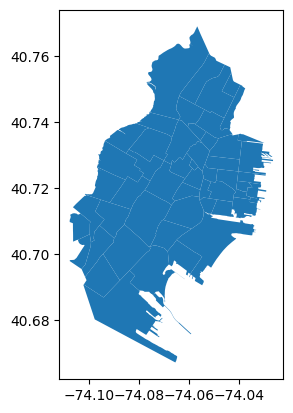

In [60]:
df.plot()

## Jersey

In [12]:
# eval: true
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

### Downloading the Citi Bike Data for `202510`

In [7]:
CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike/" # ձեզ մոտ թողեց citibike
PERIOD = "202510"

In [14]:
file_name = f"JC-{PERIOD}-citibike-tripdata.zip"
url = f"{CITIBIKE_INDEX_URL}/{file_name}"
url

'https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip'

In [ ]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True)
zip_path = output_dir / file_name

In [ ]:
print(f"Downloading: {url}")
urlretrieve(url, zip_path)

print(f"Saved ZIP file to: {zip_path}")


with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Extracted files into: {output_dir}")



Downloading: https://s3.amazonaws.com/tripdata/JC-202510-citibike-tripdata.zip
Saved ZIP file to: ../data/test/JC-202510-citibike-tripdata.zip
Extracted files into: ../data/test


### Removing the extracted ZIP file

In [66]:
zip_path.unlink()
print("ZIP file removed.")

ZIP file removed.


In [4]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

CITIBIKE_INDEX_URL = "https://s3.amazonaws.com/tripdata"
OUTPUT_DIR = "../data/citibike" # ձեզ մոտ թողեց citibike


### Function to generate periods in the format YYYYMM

In [22]:
def period_iterator(year:list,start_m:int, stop_m:int)->list:
    """
    year list of strings
    """
    YEAR = year
    MONTH =  [str(i+1) if i+1>9 else "0" + str(i+1) for i in range(start_m, stop_m)]

    periods = []

    for i in YEAR:
        for j in MONTH:
            k = i+j
            periods.append(k)
    # print(periods)
    return periods


In [23]:
PERIODS = period_iterator(["2025"],0,12)
PERIODS

['202501',
 '202502',
 '202503',
 '202504',
 '202505',
 '202506',
 '202507',
 '202508',
 '202509',
 '202510',
 '202511',
 '202512']

### Downlaoding for the Year 2025 and months from 1 to 12

In [6]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve
from urllib.error import HTTPError, URLError

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)


NameError: name 'OUTPUT_DIR' is not defined

In [ ]:

for i in PERIODS:

    try:
        file_name = f"JC-{i}-citibike-tripdata.csv.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    
    except (HTTPError, URLError, FileNotFoundError):
        file_name = f"JC-{i}-citibike-tripdata.zip"
        url = f"{CITIBIKE_INDEX_URL}/{file_name}"

        zip_path = output_dir / file_name
        urlretrieve(url, zip_path)

    
    
    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)
    print(f'{file_name}  Extracted')
    zip_path.unlink()
    print(f"{file_name} removed.")

# Oncee finishd

JC-202501-citibike-tripdata.csv.zip  Extracted
JC-202501-citibike-tripdata.csv.zip removed.
JC-202502-citibike-tripdata.csv.zip  Extracted
JC-202502-citibike-tripdata.csv.zip removed.
JC-202503-citibike-tripdata.csv.zip  Extracted
JC-202503-citibike-tripdata.csv.zip removed.
JC-202504-citibike-tripdata.csv.zip  Extracted
JC-202504-citibike-tripdata.csv.zip removed.
JC-202505-citibike-tripdata.csv.zip  Extracted
JC-202505-citibike-tripdata.csv.zip removed.
JC-202506-citibike-tripdata.csv.zip  Extracted
JC-202506-citibike-tripdata.csv.zip removed.
JC-202507-citibike-tripdata.csv.zip  Extracted
JC-202507-citibike-tripdata.csv.zip removed.
JC-202508-citibike-tripdata.csv.zip  Extracted
JC-202508-citibike-tripdata.csv.zip removed.
JC-202509-citibike-tripdata.csv.zip  Extracted
JC-202509-citibike-tripdata.csv.zip removed.
JC-202510-citibike-tripdata.zip  Extracted
JC-202510-citibike-tripdata.zip removed.
JC-202511-citibike-tripdata.csv.zip  Extracted
JC-202511-citibike-tripdata.csv.zip remov

### Removing `__MACOSX` files

In [11]:
import shutil

shutil.rmtree(output_dir)

### Concatinating all the csv files into one file

In [11]:
import glob
import numpy as np
import pandas as pd

file_names = glob.glob(f'{output_dir}/*.csv')



dfs = []
cols = []
for file_name in file_names:
    df = pd.read_csv(file_name)
    print(df.columns, 2*"||",len(df.columns))

    cols.append(list(df.columns))
    dfs.append(df)

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='str') |||| 13
Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      d

In [12]:
df =pd.concat(dfs, ignore_index=True)
df.head()

df.shape

(1002704, 13)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1002704 non-null  str    
 1   rideable_type       1002704 non-null  str    
 2   started_at          1002704 non-null  str    
 3   ended_at            1002704 non-null  str    
 4   start_station_name  1002701 non-null  str    
 5   start_station_id    1002701 non-null  str    
 6   end_station_name    999469 non-null   str    
 7   end_station_id      998307 non-null   str    
 8   start_lat           1002702 non-null  float64
 9   start_lng           1002702 non-null  float64
 10  end_lat             999260 non-null   float64
 11  end_lng             999260 non-null   float64
 12  member_casual       1002704 non-null  str    
dtypes: float64(4), str(9)
memory usage: 222.5 MB


In [19]:
df.to_csv(f"{output_dir}/JC/JC2025.csv", index=False)

### Loading JC 2025 Data

In [43]:
citibike_df = pd.read_csv(f"{output_dir}/JC/JC2025.csv", 
                          parse_dates=['started_at','ended_at'])

In [44]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1002704 non-null  str           
 1   rideable_type       1002704 non-null  str           
 2   started_at          1002704 non-null  datetime64[us]
 3   ended_at            1002704 non-null  datetime64[us]
 4   start_station_name  1002701 non-null  str           
 5   start_station_id    1002701 non-null  str           
 6   end_station_name    999469 non-null   str           
 7   end_station_id      998307 non-null   str           
 8   start_lat           1002702 non-null  float64       
 9   start_lng           1002702 non-null  float64       
 10  end_lat             999260 non-null   float64       
 11  end_lng             999260 non-null   float64       
 12  member_casual       1002704 non-null  str           
dtypes: datetime64[us](2), f

### Missing Values

In [45]:
# option 1:

citibike_df.shape[0]

# option 2:
len(citibike_df)

1002704

In [46]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['column_name', 'missing_count']

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(citibike_df)) * 100

missing_values.sort_values(by="missing_percentage", ascending=False, inplace=True)

missing_values

,column_name,missing_count,missing_percentage
7,end_station_id,4397,0.438514
10,end_lat,3444,0.343471
11,end_lng,3444,0.343471
6,end_station_name,3235,0.322628
4,start_station_name,3,0.000299
5,start_station_id,3,0.000299
8,start_lat,2,0.000199
9,start_lng,2,0.000199
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


### Data Enrichment

In [47]:
citibike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   ride_id             1002704 non-null  str           
 1   rideable_type       1002704 non-null  str           
 2   started_at          1002704 non-null  datetime64[us]
 3   ended_at            1002704 non-null  datetime64[us]
 4   start_station_name  1002701 non-null  str           
 5   start_station_id    1002701 non-null  str           
 6   end_station_name    999469 non-null   str           
 7   end_station_id      998307 non-null   str           
 8   start_lat           1002702 non-null  float64       
 9   start_lng           1002702 non-null  float64       
 10  end_lat             999260 non-null   float64       
 11  end_lng             999260 non-null   float64       
 12  member_casual       1002704 non-null  str           
dtypes: datetime64[us](2), f

#### Duration

In [48]:
citibike_df['ride_duration_min'] = (citibike_df["ended_at"] - citibike_df["started_at"]).dt.total_seconds()/60

In [49]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383


In [50]:
citibike_df.shape

(1002704, 14)

In [51]:
citibike_df = citibike_df[
    (citibike_df['ride_duration_min']>1) & (citibike_df['ride_duration_min']<24*60)
]

citibike_df.shape


(1002333, 14)

In [52]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['column_name', 'missing_count']

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(citibike_df)) * 100

missing_values.sort_values(by="missing_percentage", ascending=False, inplace=True)

missing_values

,column_name,missing_count,missing_percentage
7,end_station_id,4049,0.403958
10,end_lat,3106,0.309877
11,end_lng,3106,0.309877
6,end_station_name,2887,0.288028
4,start_station_name,3,0.000299
5,start_station_id,3,0.000299
8,start_lat,2,0.000200
9,start_lng,2,0.000200
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


#### Droping Missing Values

In [53]:
citibike_df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'ride_duration_min'],
      dtype='str')

In [54]:
['ride_id', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
        ]

['ride_id',
 'started_at',
 'ended_at',
 'start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id',
 'start_lat',
 'start_lng',
 'end_lat',
 'end_lng']

In [55]:
citibike_df = citibike_df.dropna(
    subset=['ride_id', 'started_at', 'ended_at','start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
        ]
)

In [56]:
missing_values = citibike_df.isnull().sum().reset_index()

missing_values.columns = ['column_name', 'missing_count']

missing_values["missing_percentage"] = (missing_values["missing_count"] / len(citibike_df)) * 100

missing_values.sort_values(by="missing_percentage", ascending=False, inplace=True)

missing_values

,column_name,missing_count,missing_percentage
0,ride_id,0,0.0
1,rideable_type,0,0.0
2,started_at,0,0.0
3,ended_at,0,0.0
4,start_station_name,0,0.0
5,start_station_id,0,0.0
6,end_station_name,0,0.0
7,end_station_id,0,0.0
8,start_lat,0,0.0
9,start_lng,0,0.0


#### Adding time granularity

In [57]:
citibike_df['date'] = citibike_df['started_at'].dt.date
citibike_df['month'] = citibike_df['started_at'].dt.to_period('M').astype(str)
citibike_df['month_name'] = citibike_df['started_at'].dt.month_name()
citibike_df['month_number'] = citibike_df['started_at'].dt.month
citibike_df['day_of_week'] = citibike_df['started_at'].dt.day_name()
citibike_df['hour'] = citibike_df['started_at'].dt.hour

In [58]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min,date,month,month_name,month_number,day_of_week,hour
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,11,Tuesday,18
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,11,Wednesday,16
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,11,Tuesday,22
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,11,Saturday,6
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,11,Monday,20


In [59]:
def assign_season(month_number):
    if month_number in [12,1,2]:
        return 'Winter'
    elif month_number in [3,4,5]:
        return 'Spring'
    elif month_number in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'

In [60]:
citibike_df['season'] = citibike_df['month_number'].apply(assign_season)

citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,month_name,month_number,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,13.307467,2025-11-18,2025-11,November,11,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,14.495367,2025-11-26,2025-11,November,11,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,...,-74.042521,member,6.983450,2025-11-04,2025-11,November,11,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,5.803383,2025-11-08,2025-11,November,11,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,6.658383,2025-11-24,2025-11,November,11,Monday,20,Autumn


#### Storing Enriched Data 

In [61]:
citibike_df.to_csv(f'{output_dir}/JC/JC2025_Enriched.csv',index=False)

### Getting Weather

In [62]:

import requests

lat = 40.7178
lng = -74.0431

start_date = "2025-01-01"
end_date = "2025-12-31"

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lng,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "rain_sum",
        "snowfall_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "America/New_York"
}

response = requests.get(url, params=params)
response.raise_for_status()

In [63]:
data = response.json()

In [64]:
data['daily'].keys()

dict_keys(['time', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max'])

In [65]:
weather_data = pd.DataFrame(data['daily'])
weather_data.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [66]:
weather_data.rename(columns={'time':'date'},inplace=True)
weather_data.to_csv(f'{output_dir}/JC/jersey_weather_2025.csv',index=False)

In [67]:
weather_daily = pd.read_csv(f'{output_dir}/JC/jersey_weather_2025.csv', parse_dates=['date'])
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 365 non-null    datetime64[us]
 1   temperature_2m_max   365 non-null    float64       
 2   temperature_2m_min   365 non-null    float64       
 3   temperature_2m_mean  365 non-null    float64       
 4   precipitation_sum    365 non-null    float64       
 5   rain_sum             365 non-null    float64       
 6   snowfall_sum         365 non-null    float64       
 7   wind_speed_10m_max   365 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


In [68]:
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [69]:
weather_daily = pd.read_csv(f'{output_dir}/JC/jersey_weather_2025.csv', parse_dates=['date'])
weather_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 365 non-null    datetime64[us]
 1   temperature_2m_max   365 non-null    float64       
 2   temperature_2m_min   365 non-null    float64       
 3   temperature_2m_mean  365 non-null    float64       
 4   precipitation_sum    365 non-null    float64       
 5   rain_sum             365 non-null    float64       
 6   snowfall_sum         365 non-null    float64       
 7   wind_speed_10m_max   365 non-null    float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 22.9 KB


In [70]:
### 
fig = px.line(
    weather_daily,
    x="date",
    y="temperature_2m_mean",
    title="Daily Average Temperature Over Time",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Temperature",
    hovermode="x unified"
)

fig.show()

In [71]:
### wide format
weather_daily.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2025-01-01,10.9,3.9,7.4,4.5,4.5,0.0,23.2
1,2025-01-02,5.4,0.3,2.6,0.0,0.0,0.0,25.1
2,2025-01-03,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
3,2025-01-04,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1
4,2025-01-05,0.3,-3.6,-2.2,0.0,0.0,0.0,19.9


In [72]:
# date, temperature, type գունավորի

In [73]:
temperature_long = weather_daily.melt(
    id_vars = 'date',
    value_vars = [
        'temperature_2m_max',	'temperature_2m_min',	'temperature_2m_mean'
    ],

    var_name = 'temperature_type',
    value_name = 'temperature'
)

temperature_long.head()

,date,temperature_type,temperature
0,2025-01-01,temperature_2m_max,10.9
1,2025-01-02,temperature_2m_max,5.4
2,2025-01-03,temperature_2m_max,3.2
3,2025-01-04,temperature_2m_max,-0.1
4,2025-01-05,temperature_2m_max,0.3


### Homework Part 1

1. փորձեք ջնջել `tempreture_` բառը `temerature_type` սյան միջից
2. քամին և տեղումները

In [74]:
### 
fig = px.line(
    temperature_long,
    x="date",
    y="temperature",
    color = 'temperature_type',
    title="Daily Temperature Over Time: Min, Max, Mean",
    markers=False
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Temperature",
    hovermode="x unified"
)

fig.show()

### Monthly Rides

In [75]:
citibike_df.info()

<class 'pandas.DataFrame'>
Index: 998281 entries, 0 to 1002703
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             998281 non-null  str           
 1   rideable_type       998281 non-null  str           
 2   started_at          998281 non-null  datetime64[us]
 3   ended_at            998281 non-null  datetime64[us]
 4   start_station_name  998281 non-null  str           
 5   start_station_id    998281 non-null  str           
 6   end_station_name    998281 non-null  str           
 7   end_station_id      998281 non-null  str           
 8   start_lat           998281 non-null  float64       
 9   start_lng           998281 non-null  float64       
 10  end_lat             998281 non-null  float64       
 11  end_lng             998281 non-null  float64       
 12  member_casual       998281 non-null  str           
 13  ride_duration_min   998281 non-null  float64

In [76]:
monthly_rides = (citibike_df
                 .groupby('month',as_index=False)
                 .agg(number_of_rides = ('ride_id',"count"))
                 )
monthly_rides

,month,number_of_rides
0,2024-12,2
1,2025-01,50477
2,2025-02,45131
3,2025-03,73124
4,2025-04,81295
5,2025-05,92880
6,2025-06,96736
7,2025-07,107374
8,2025-08,108001
9,2025-09,115580


In [77]:
fig = px.bar(
    monthly_rides,
    x="month",
    y="number_of_rides",
    title="Number of Citi Bike Rides per Month"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Rides",
)

fig.show()

In [79]:
citibike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,ride_duration_min,date,month,month_name,month_number,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,13.307467,2025-11-18,2025-11,November,11,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,...,-74.093680,member,14.495367,2025-11-26,2025-11,November,11,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,...,-74.042521,member,6.983450,2025-11-04,2025-11,November,11,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,5.803383,2025-11-08,2025-11,November,11,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,...,-74.042521,member,6.658383,2025-11-24,2025-11,November,11,Monday,20,Autumn



### Homework Part 2

**Try to visualize:**

- Day_of_week
  - Highlight the highest and lowest days ()
- Seasons
- Hourly
    - Morning
    - Daytime
    - Eveninng
    


### Top Start Stations

In [81]:
top_stations = (citibike_df
                .groupby('start_station_name', as_index=False)
                .agg(number_of_departures= ('ride_id','count') )
                .sort_values("number_of_departures",ascending=False)
                .head(10))

top_stations

,start_station_name,number_of_departures
52,Grove St PATH,44984
58,Hoboken Terminal - Hudson St & Hudson Pl,25879
53,Hamilton Park,22232
95,River St & Newark St,21383
86,Newport PATH,20641
18,Bergen Ave & Sip Ave,20370
44,Exchange Pl,19982
0,11 St & Washington St,19469
94,River St & 1 St,19125
87,Newport Pkwy,18709


### Top End Stations 

In [82]:
N = 15
top_stations = (citibike_df
                .groupby('end_station_name', as_index=False)
                .agg(number_of_arrivals = ('ride_id','count') )
                .sort_values("number_of_arrivals",ascending=False)
                .head(N))

top_stations

,end_station_name,number_of_arrivals
232,Grove St PATH,47744
241,Hoboken Terminal - Hudson St & Hudson Pl,26638
233,Hamilton Park,22347
347,River St & Newark St,22113
317,Newport PATH,20698
73,Bergen Ave & Sip Ave,20357
207,Exchange Pl,20142
7,11 St & Washington St,19501
318,Newport Pkwy,18704
346,River St & 1 St,18515


In [83]:
fig = px.bar(
    data_frame=top_stations,
    x = 'number_of_arrivals',
    y = 'end_station_name',
    orientation = 'h',
    title=f"Top {N} Stations by Number of Departures",
    text_auto= True

)
fig.update_layout(
    xaxis_title="Number of Arrivals",
    yaxis_title="End Station"
)


fig.show()

In [84]:
# փորձեք միացնել ստարտը և էնդը մի թեյբլի մեջ ու մեկ փոփոխությամբ փոխեք վիզուալիցացիան

### Merging with weather Data

In [85]:
daily_rides = (citibike_df
               .groupby('date', as_index=False)
               .agg(number_of_daily_rides = ('ride_id','count'))
               )


daily_rides['date'] = pd.to_datetime(daily_rides['date'])
daily_rides.head()

,date,number_of_daily_rides
0,2024-12-31,2
1,2025-01-01,1174
2,2025-01-02,1709
3,2025-01-03,1764
4,2025-01-04,1336


In [86]:
bike_weather_daily = daily_rides.merge(weather_daily,
                                       on='date',
                                       how = 'left')

bike_weather_daily.head()

,date,number_of_daily_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,1174,10.9,3.9,7.4,4.5,4.5,0.0,23.2
2,2025-01-02,1709,5.4,0.3,2.6,0.0,0.0,0.0,25.1
3,2025-01-03,1764,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
4,2025-01-04,1336,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1


#### Rides vs Average Temperature

In [87]:
fig = px.scatter(
    data_frame = bike_weather_daily,
    x = 'temperature_2m_mean',
    y = 'number_of_daily_rides',
    trendline = 'ols',
    title="Daily Rides vs Average Temperature"
)

fig.update_layout(
    xaxis_title="Average Daily Temperature",
    yaxis_title="Number of Rides"
)

fig.show()

In [88]:
fig = px.scatter(
    data_frame = bike_weather_daily,
    x = 'wind_speed_10m_max',
    y = 'number_of_daily_rides',
    trendline = 'ols',
    title="Daily Rides vs Wind Spead"
)

fig.update_layout(
    xaxis_title="Wind Spead",
    yaxis_title="Number of Rides"
)

fig.show()

In [89]:
fig = px.scatter(
    data_frame = bike_weather_daily,
    x = 'wind_speed_10m_max',
    y = 'number_of_daily_rides',
    trendline = 'ols',
    title="Daily Rides vs Wind Spead"
)

fig.update_layout(
    xaxis_title="Wind Spead",
    yaxis_title="Number of Rides"
)

fig.show()

## Dual Axis

In [90]:
bike_weather_daily.head()

,date,number_of_daily_rides,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max
0,2024-12-31,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,1174,10.9,3.9,7.4,4.5,4.5,0.0,23.2
2,2025-01-02,1709,5.4,0.3,2.6,0.0,0.0,0.0,25.1
3,2025-01-03,1764,3.2,-1.9,0.4,0.0,0.0,0.0,17.1
4,2025-01-04,1336,-0.1,-2.7,-1.4,0.0,0.0,0.0,26.1


In [91]:
import plotly.graph_objects as go


fig = go.Figure()


fig.add_trace(
    go.Scatter(
        x = bike_weather_daily['date'],
        y = bike_weather_daily['number_of_daily_rides'],
        mode = 'lines',
        name = 'Daily Rides',
        yaxis = 'y1' 
    )
)

fig.add_trace(
    go.Scatter(
        x = bike_weather_daily['date'],
        y = bike_weather_daily['temperature_2m_mean'],
        mode = 'lines',
        name = 'Daily Average Temperature',
        yaxis = 'y2' 
    )
)

fig.update_layout(
    title = '',
    xaxis = dict(title = 'Day'),
    yaxis = dict(title = 'Daily Rides', side = 'left'),
    yaxis2 = dict(title = 'Temperature', side = 'right', overlaying = 'y'),
    hovermode = 'x unified'


)


fig.show()

### Geopandas

In [96]:
import geopandas as gpd
from urllib.parse import urlencode
from pathlib import Path

url = '../data/citibike/JC/jersey-city-neighborhoods.geojson'

# '.shp'

jersey_city = gpd.read_file(url)

jersey_city


,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."
5,28,411601381.8,9449.068,Journal Square,Mill Creek,NaN,-74.057806,40.722897,"POLYGON ((-74.05563 40.71949, -74.06042 40.721..."
6,3,411601381.8,9449.068,Heights,Meadowlands,NaN,-74.065425,40.754461,"POLYGON ((-74.05208 40.76084, -74.05231 40.760..."
7,16,411601381.8,9449.068,Downtown,Metroplaza,26.0,-74.036622,40.723239,"POLYGON ((-74.03151 40.72119, -74.03535 40.721..."
8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255,"POLYGON ((-74.03709 40.73404, -74.03062 40.733..."
9,50,411601381.8,9449.068,Downtown,Hoboken Yards,22.0,-74.037012,40.734961,"POLYGON ((-74.03918 40.73633, -74.03882 40.736..."


### Homewort Part 3

փորձենք ավելացնել բնակչության թիվը ըստ թաղամասի, և հաշվել խտությունը

>BONUS
փորձենք կոնվերտացենլ ֆուտը կիլոմետրի

<Axes: >

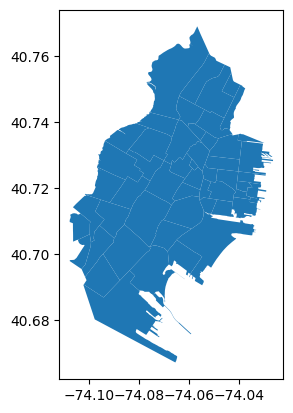

In [98]:
jersey_city.plot()

In [99]:
jersey_city = jersey_city.to_crs("EPSG:4326")

### Departures

In [104]:
citibike_df.shape

(998281, 21)

In [105]:
start_stations = citibike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()


start_stations.rename(columns= {"start_station_id":'station_id',
        "start_station_name":'station_name',
        "start_lat": 'lat',
        "start_lng": 'lng'},
        inplace=True
                      )

start_stations["activity_type"] = "departure"

start_stations.head()


,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC094,Glenwood Ave,40.727551,-74.071061,departure
1,B6C773B13AC0E465,JC094,Glenwood Ave,40.727551,-74.071061,departure
2,C300465AA158280F,HB203,Bloomfield St & 15 St,40.754530,-74.026580,departure
3,31A424FC97C8AAFB,HB303,Clinton St & 7 St,40.745420,-74.033320,departure
4,08C5EA04CB1FDC57,HB303,Clinton St & 7 St,40.745420,-74.033320,departure


In [ ]:
end_stations = citibike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()


end_stations.rename(columns= {"end_station_id":'station_id',
        "end_station_name":'station_name',
        "end_lat": 'lat',
        "end_lng": 'lng'},
        inplace=True
                      )

end_stations["activity_type"] = "arrival"
end_stations.head()


,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
1,B6C773B13AC0E465,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
2,C300465AA158280F,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
3,31A424FC97C8AAFB,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
4,08C5EA04CB1FDC57,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival


In [110]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)


station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC094,Glenwood Ave,40.727551,-74.071061,departure
1,B6C773B13AC0E465,JC094,Glenwood Ave,40.727551,-74.071061,departure
2,C300465AA158280F,HB203,Bloomfield St & 15 St,40.754530,-74.026580,departure
3,31A424FC97C8AAFB,HB303,Clinton St & 7 St,40.745420,-74.033320,departure
4,08C5EA04CB1FDC57,HB303,Clinton St & 7 St,40.745420,-74.033320,departure


In [111]:
station_activity_long['activity_type'].value_counts()

activity_type
departure    998281
arrival      998281
Name: count, dtype: int64

In [114]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    ).sort_values(by = [ 'activity_type','number_of_rides'], ascending=False)
)

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
547,JC115,Grove St PATH,40.719410,-74.043090,departure,44984
377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,departure,25879
451,JC009,Hamilton Park,40.727596,-74.044247,departure,22232
385,HB106,River St & Newark St,40.736722,-74.029007,departure,21383
495,JC066,Newport PATH,40.727224,-74.033759,departure,20641


In [ ]:
station_activity_agg.sort_values(by = ['activity_type','number_of_rides'], 
                                 ascending=[True,False]).head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
546,JC115,Grove St PATH,40.719410,-74.043090,arrival,47744
376,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,arrival,26638
450,JC009,Hamilton Park,40.727596,-74.044247,arrival,22347
384,HB106,River St & Newark St,40.736722,-74.029007,arrival,22113
494,JC066,Newport PATH,40.727224,-74.033759,arrival,20698


In [121]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 4.8 KB


In [122]:

station_activity_agg.head()

,station_id,station_name,lat,lng,activity_type,number_of_rides
547,JC115,Grove St PATH,40.719410,-74.043090,departure,44984
377,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,departure,25879
451,JC009,Hamilton Park,40.727596,-74.044247,departure,22232
385,HB106,River St & Newark St,40.736722,-74.029007,departure,21383
495,JC066,Newport PATH,40.727224,-74.033759,departure,20641


In [135]:
station_summary = station_activity_agg.pivot_table(
    index= [
            "station_id",
            "station_name",
            "lat",
            "lng"
     ],
     columns= "activity_type",
     values = "number_of_rides",
     fill_value=0

).reset_index()

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


In [137]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.sort_values(by= 'net_departures', ascending=True).head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0
15,HB102,Hoboken Terminal - River St & Hudson Pl,40.736068,-74.029127,18073.0,16757.0,34830.0,-1316.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
96,5297.02,Vesey Pl & River Terrace,40.715338,-74.016584,469.0,0.0,469.0,-469.0


In [138]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722)


<Axes: >

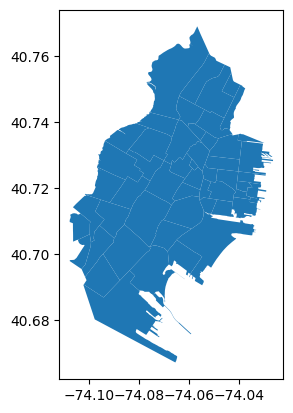

In [140]:
jersey_city.plot()

<Axes: >

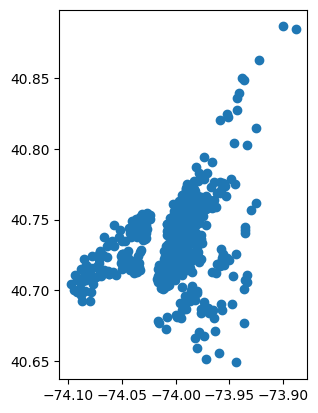

In [ ]:
station_gdf.plot()

In [142]:
station_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   station_id        488 non-null    str     
 1   station_name      488 non-null    str     
 2   lat               488 non-null    float64 
 3   lng               488 non-null    float64 
 4   total_arrivals    488 non-null    float64 
 5   total_departures  488 non-null    float64 
 6   total_activity    488 non-null    float64 
 7   net_departures    488 non-null    float64 
 8   geometry          488 non-null    geometry
dtypes: float64(6), geometry(1), str(2)
memory usage: 46.9 KB


In [141]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cartodb_id    53 non-null     int32   
 1   area_sq_ft    53 non-null     float64 
 2   acres         53 non-null     float64 
 3   area          53 non-null     str     
 4   neighborhood  53 non-null     str     
 5   color         18 non-null     float64 
 6   lon           53 non-null     float64 
 7   lat           53 non-null     float64 
 8   geometry      53 non-null     geometry
dtypes: float64(5), geometry(1), int32(1), str(2)
memory usage: 4.8 KB


In [ ]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

### Lines

In [143]:
route_summary = (
    citibike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

In [145]:
route_summary.head()


,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750


In [147]:
route_summary["route"] = (
    route_summary["start_station_id"] +
    " → " +
    route_summary["end_station_id"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,HB101 → JC105
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,JC055 → JC109
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,JC115 → JC013
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,JC013 → JC115
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,JC115 → JC052


In [148]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
83,HB101 → JC105,4559
5583,JC055 → JC109,4306
8709,JC115 → JC013,4131
3937,JC013 → JC115,3831
8723,JC115 → JC052,3750
8445,JC109 → JC055,3609
5395,JC052 → JC115,3605
8154,JC105 → HB101,3257
4570,JC023 → JC115,3175
3788,JC009 → JC115,2998


In [ ]:
import folium

top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

max_rides






np.float64(8.556042991884185)

In [154]:


for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8 #կարող ենք օգտագործել գունային տարբեր երանգներ ստանալու համար

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

## Homework 4: թոփ 5 ռայդերը ուրիշ գույնով

In [ ]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat_right
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941),49,2,411601381.8,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276),10,18,411601381.8,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722),8,12,411601381.8,9449.068,Downtown,Newport,22.0,-74.034927,40.729255
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20370.0,40727.0,13.0,POINT (-74.06444 40.73101),16,31,411601381.8,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,19982.0,40124.0,-160.0,POINT (-74.03434 40.71637),48,13,411601381.8,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458


In [ ]:
print(station_gdf.shape)
print(station_neighborhood.shape)

(488, 9)
(79, 18)


In [160]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures
0,Bayside,2,50.0,59.0,109.0,-9.0
1,Bergen Hill,4,23776.0,22888.0,46664.0,888.0
2,Exchange Place,1,19982.0,20142.0,40124.0,-160.0
3,Gregory Park,1,16214.0,16149.0,32363.0,65.0
4,Hamilton Park,2,31729.0,31922.0,63651.0,-193.0
5,Harbor Place,1,10630.0,10563.0,21193.0,67.0
6,Harborside,1,12159.0,12188.0,24347.0,-29.0
7,Harsimus Cove,3,30142.0,30117.0,60259.0,25.0
8,Hudson City,1,3651.0,3212.0,6863.0,439.0
9,Jackson Hill,16,6142.0,6045.0,12187.0,97.0


In [162]:
neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,96144.0,98853.0,194997.0,-2709.0,32499.500000
17,Palus Hook,6,59496.0,59160.0,118656.0,336.0,19776.000000
14,Newport,2,39350.0,39402.0,78752.0,-52.0,39376.000000
10,Journal Square,3,32970.0,32560.0,65530.0,410.0,21843.333333
4,Hamilton Park,2,31729.0,31922.0,63651.0,-193.0,31825.500000


<Axes: >

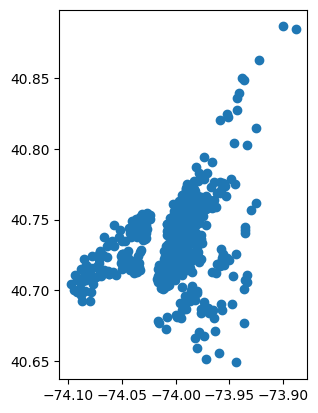

In [163]:
station_gdf.plot()

In [164]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.7340122586309), np.float64(-74.00137516113631))

In [165]:

station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

station_point_map

In [166]:
for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

In [169]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.0000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30845.0,30730.0,61575.0,115.0,10262.5000
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6142.0,6045.0,12187.0,97.0,761.6875


In [2]:
import geopandas as gpd
gpd.read_file('https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json')

,id,name,geometry
0,AL,Alabama,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
1,AK,Alaska,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691..."
2,AZ,Arizona,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,AR,Arkansas,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,CA,California,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."
5,CO,Colorado,"POLYGON ((-107.91973 41.00391, -105.72895 40.9..."
6,CT,Connecticut,"POLYGON ((-73.05353 42.03905, -71.79931 42.022..."
7,DE,Delaware,"POLYGON ((-75.41409 39.80446, -75.5072 39.6839..."
8,FL,Florida,"POLYGON ((-85.49714 30.99754, -85.00421 31.003..."
9,GA,Georgia,"POLYGON ((-83.10919 35.00118, -83.32279 34.787..."
